In [1070]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RSEED = 42

In [1071]:
df_delayed_flights = pd.read_csv("data/Train.csv")

In [1072]:
df_delayed_flights.columns = ["ID", "flight_date", "flight_number", "airport_departure", "airport_arrival", "sch_time_dep", "sch_time_arr", "status", "aircraft_code", "delay"]
df_delayed_flights["sch_time_dep"] = pd.to_datetime(df_delayed_flights["sch_time_dep"])
df_delayed_flights["sch_time_dep"] = df_delayed_flights["sch_time_dep"].astype("datetime64[ns]")

df_delayed_flights["sch_time_arr"] = df_delayed_flights["sch_time_arr"].str.replace(".", ":")
df_delayed_flights["sch_time_arr"] = pd.to_datetime(df_delayed_flights["sch_time_arr"])
df_delayed_flights["sch_time_arr"] = df_delayed_flights["sch_time_arr"].astype("datetime64[ns]")

df_delayed_flights["sch_time_dep_hour"] = df_delayed_flights["sch_time_dep"].dt.hour
df_delayed_flights["sch_time_dep_day"] = df_delayed_flights["sch_time_dep"].dt.day
df_delayed_flights["sch_time_dep_month"] = df_delayed_flights["sch_time_dep"].dt.month


In [1073]:
df_delayed_flights.columns

Index(['ID', 'flight_date', 'flight_number', 'airport_departure',
       'airport_arrival', 'sch_time_dep', 'sch_time_arr', 'status',
       'aircraft_code', 'delay', 'sch_time_dep_hour', 'sch_time_dep_day',
       'sch_time_dep_month'],
      dtype='object')

In [1074]:
# Remove Outliers
df_delayed_flights = df_delayed_flights[df_delayed_flights["delay"] < 240.0]
df_delayed_flights.shape[0]

102999

In [1075]:
# Balance of flights with delay and without delay
raw_data_delays = int(df_delayed_flights[df_delayed_flights["delay"] > 0.0].shape[0])
raw_data_no_delays = int(df_delayed_flights[df_delayed_flights["delay"] == 0.0].shape[0])
raw_data_overall = int(df_delayed_flights["delay"].shape[0])

print("Flights with delay: " + str(round((raw_data_delays) * 100 / raw_data_overall,2)) + " %")
print("Flights without delay: " + str(round((raw_data_no_delays) * 100 / raw_data_overall,2)) + " %")

Flights with delay: 62.94 %
Flights without delay: 37.06 %


In [1076]:
top_ten_dep_airports = df_delayed_flights["airport_departure"].value_counts().head(10).index.tolist()
print(top_ten_dep_airports)

top_ten_arr_airports = df_delayed_flights["airport_arrival"].value_counts().head(10).index.tolist()
print(top_ten_arr_airports)


['TUN', 'DJE', 'ORY', 'MIR', 'MRS', 'LYS', 'NCE', 'MXP', 'ALG', 'FRA']
['TUN', 'DJE', 'ORY', 'MIR', 'MRS', 'LYS', 'NCE', 'MXP', 'ALG', 'FRA']


In [1077]:
df_delayed_flights = df_delayed_flights[df_delayed_flights["airport_departure"].isin(top_ten_dep_airports) & df_delayed_flights["airport_arrival"].isin(top_ten_arr_airports)]
df_delayed_flights.airport_departure.value_counts(ascending=False)
df_delayed_flights.airport_arrival.value_counts(ascending=False)

df_delayed_flights.airport_arrival.value_counts()

airport_arrival
TUN    21098
DJE     7115
ORY     6358
MIR     3297
MRS     2658
LYS     2172
NCE     2131
MXP     1466
ALG     1438
FRA     1236
Name: count, dtype: int64

In [1078]:
df_delayed_flights["airport_departure"] = df_delayed_flights["airport_departure"].replace(top_ten_dep_airports, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
df_delayed_flights["airport_arrival"] = df_delayed_flights["airport_arrival"].replace(top_ten_arr_airports, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
df_delayed_flights.airport_departure.value_counts()
df_delayed_flights.airport_arrival.value_counts()

/var/folders/8w/dmpm9m8525x38x65g4z96bsm0000gn/T/ipykernel_36880/2570058211.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delayed_flights["airport_departure"] = df_delayed_flights["airport_departure"].replace(top_ten_dep_airports, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
/var/folders/8w/dmpm9m8525x38x65g4z96bsm0000gn/T/ipykernel_36880/2570058211.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delayed_flights["airport_arrival"] = df_delayed_flights["airport_arrival"].replace(top_ten_arr_airports, [1, 2, 3, 4, 5, 6, 7, 8, 9,

airport_arrival
1     21098
2      7115
3      6358
4      3297
5      2658
6      2172
7      2131
8      1466
9      1438
10     1236
Name: count, dtype: int64

In [1079]:
df_delayed_flights["status"].value_counts()

status
ATA    38635
SCH    10017
RTR      240
DEL       64
DEP       13
Name: count, dtype: int64

In [1080]:
df_delayed_flights["status"].value_counts()

status
ATA    38635
SCH    10017
RTR      240
DEL       64
DEP       13
Name: count, dtype: int64

In [1081]:
df_delayed_flights["status"] = df_delayed_flights["status"].replace(["ATA", "SCH", "DEP", "RTR", "DEL"], [1, 2, 3, 4, 5])
df_delayed_flights["status"].value_counts()

/var/folders/8w/dmpm9m8525x38x65g4z96bsm0000gn/T/ipykernel_36880/700229096.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delayed_flights["status"] = df_delayed_flights["status"].replace(["ATA", "SCH", "DEP", "RTR", "DEL"], [1, 2, 3, 4, 5])


status
1    38635
2    10017
4      240
5       64
3       13
Name: count, dtype: int64

<Axes: >

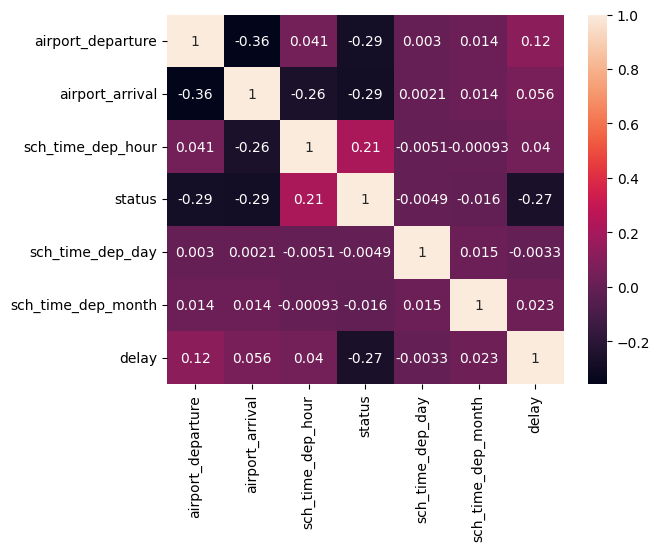

In [1082]:
sns.heatmap(data=df_delayed_flights[["airport_departure", "airport_arrival", "sch_time_dep_hour", "status", "sch_time_dep_day", "sch_time_dep_month", "delay"]].corr(), annot=True)

## Train test split

In [1083]:
columns_to_scale = ["airport_departure", "airport_arrival", "sch_time_dep_hour", "sch_time_dep_day", "sch_time_dep_month",  "status"]

X = df_delayed_flights[columns_to_scale]
y = df_delayed_flights["delay"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RSEED)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

## Baseline model

All flights with departure time between 7 am and 10 am have a delay, as we assume that in the morning rush hour there will be a lot of flights leaving and this will have a negative influence on the punctuality.

In [1084]:
def baseline_model(row):
    
    dep_hour = row['sch_time_dep_hour']
    
    if 7>= dep_hour <= 10:
        return 15.0
    else:
        return 0.0
    
# Apply baseline model to each row in the DataFrame
y_train_pred_baseline = df_train.apply(baseline_model, axis=1)
y_test_pred_baseline = df_test.apply(baseline_model, axis=1)

In [1085]:
# Create the baseline model
X_base = df_test["sch_time_dep_hour"]
y_base = df_test["delay"]

In [1086]:
# Predict the percentage of delayed flights in the morning between 7 am and 10 am
df_base = df_test[(df_test["sch_time_dep_hour"] >= 7) & (df_test["sch_time_dep_hour"] <= 10)]

delays = int(df_base[df_base["delay"] > 0.0].shape[0])
no_delays = int(df_base[df_base["delay"] == 0.0].shape[0])
overall = int(df_base["delay"].shape[0])

print("Flights with delay: " + str(round((delays) * 100 / overall,2)) + " %")
print("Flights without delay: " + str(round((no_delays) * 100 / overall,2)) + " %")

Flights with delay: 66.99 %
Flights without delay: 33.01 %


## Using the standard scaler

In [1087]:
scaler = StandardScaler()

# Fit & Transform: Calculate mean/standard deviation und transform
df_delayed_flights[columns_to_scale] = scaler.fit_transform(df_delayed_flights[columns_to_scale])

# Important: apply only .transform() on the test set, not fit !!!
df_delayed_flights[columns_to_scale] = scaler.transform(df_delayed_flights[columns_to_scale])

## Linear Regression model

In [1088]:
lin_reg = LinearRegression().fit(X_train, y_train)

y_pred_train = lin_reg.predict(X_train)
y_pred_test = lin_reg.predict(X_test)
y_pred_train = np.clip(y_pred_train, 0, None)
y_pred_test = np.clip(y_pred_test, 0, None)

In [1089]:
print(lin_reg.intercept_, lin_reg.coef_)

42.24787499452311 [  0.71821914   0.25596211   0.90371572  -0.05668706   0.25092336
 -25.12571971]


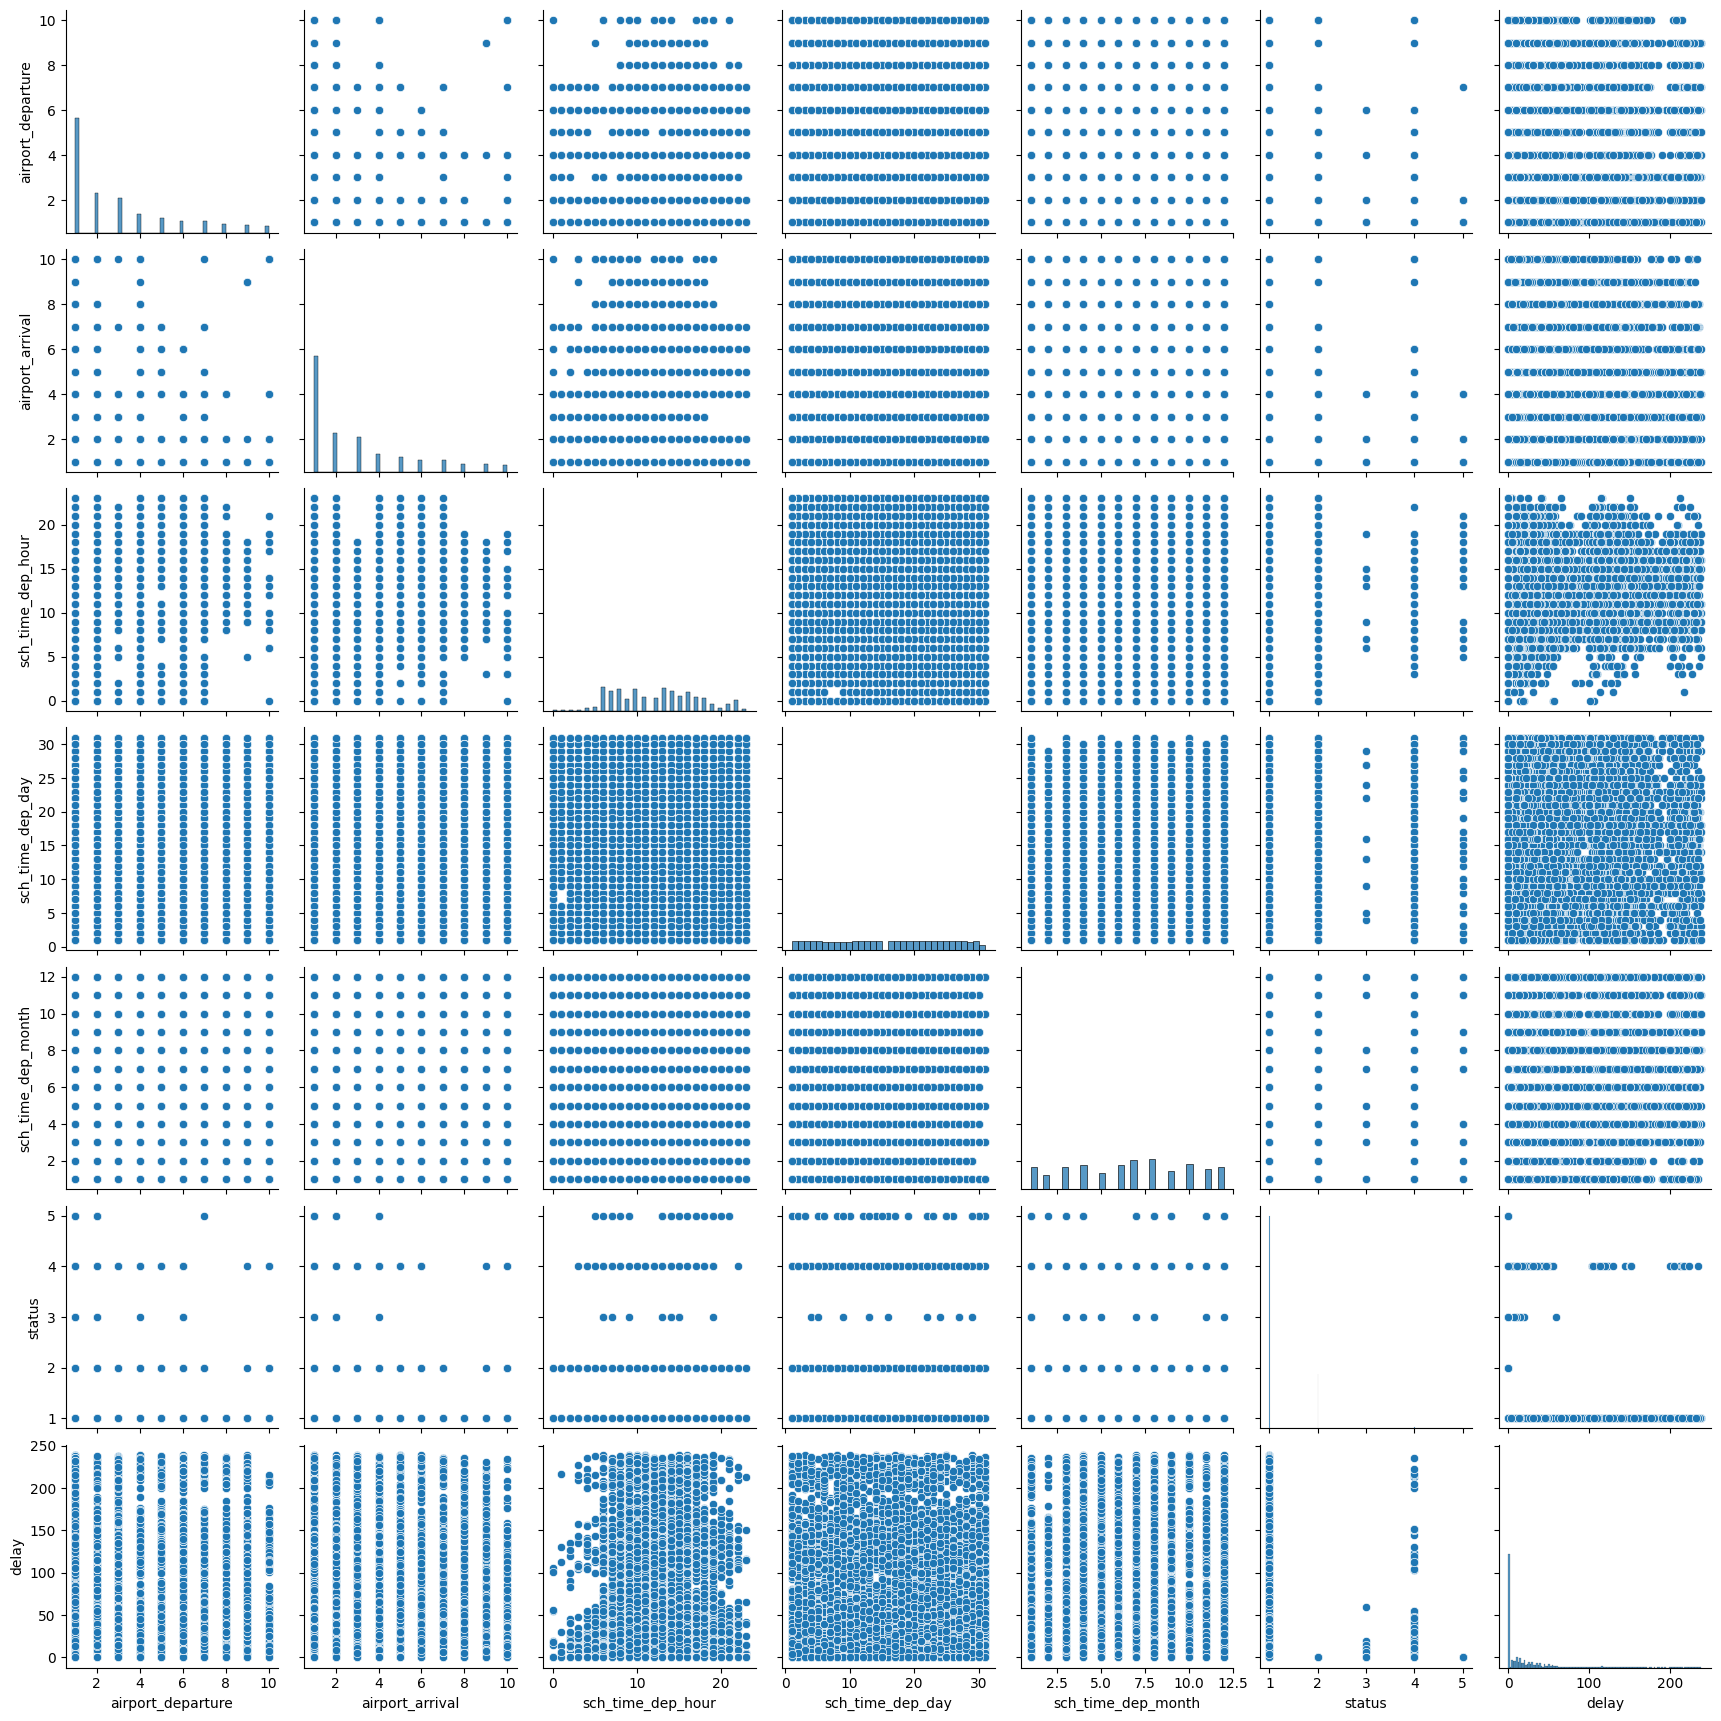

In [1090]:
sns.pairplot(df_train);

In [1091]:
print("Top ten airport delay distributed by raw delay time")
print("How many flights are delayed?")
print(df_train["delay"].shape[0])
print("How many Delays have a time of more then 2 hours?")
print(df_train[df_train["delay"] > 120.0].shape[0])
print(str(round(int(df_train[df_train["delay"] > 120.0].shape[0]) / int(df_train["delay"].shape[0]),3) * 100) + "%")
print("How many Delays have a time of more then 4 hours?")
print(df_train[df_train["delay"] > 240.0].shape[0])
print(str(round(int(df_train[df_train["delay"] > 240.0].shape[0]) / int(df_train["delay"].shape[0]),3) * 100) + "%")
print("How many Delays have a time of more then 8 hours?")
print(df_train[df_train["delay"] > 480.0].shape[0])
print(str(round(int(df_train[df_train["delay"] > 480.0].shape[0]) / int(df_train["delay"].shape[0]),3) * 100) + "%")

Top ten airport delay distributed by raw delay time
How many flights are delayed?
36726
How many Delays have a time of more then 2 hours?
2287
6.2%
How many Delays have a time of more then 4 hours?
0
0.0%
How many Delays have a time of more then 8 hours?
0
0.0%


In [1092]:
baseline_pred_delays = int(y_test_pred_baseline[y_test_pred_baseline == 15.0].shape[0])
baseline_pred_no_delays = int(y_test_pred_baseline[y_test_pred_baseline == 0.0].shape[0])
baseline_pred_overall = int(y_test_pred_baseline.shape[0])

print("Flights with delay: " + str(round((baseline_pred_delays) * 100 / baseline_pred_overall,2)) + " %")
print("Flights without delay: " + str(round((baseline_pred_no_delays) * 100 / baseline_pred_overall,2)) + " %")

# 3 -> 1/5 von 15

baseline_pred_sum_delays = y_test_pred_baseline.sum()
baseline_pred_mean_delay = y_test_pred_baseline.mean()
print("The mean delay predicted for the baseline models contains " + str(baseline_pred_delays) + " delays with an average of " + str(round(baseline_pred_mean_delay,0)))

Flights with delay: 19.95 %
Flights without delay: 80.05 %
The mean delay predicted for the baseline models contains 2442 delays with an average of 3.0


In [1093]:
# Calculate the R-squared for our model
print("R-squared:", round(r2_score(y_train, y_train_pred_baseline), 3))
print("R-squared:", round(r2_score(y_test, y_test_pred_baseline), 3))

R-squared: -0.343
R-squared: -0.343


In [1094]:
print("Train Mean and Median:")
print(round(df_train.delay.mean(),2))
print(round(df_train.delay.median(),2))

print("Test Mean and Median:")
print(round(df_test.delay.mean(),2))
print(round(df_test.delay.median(),2))

Train Mean and Median:
26.32
9.0
Test Mean and Median:
26.44
9.0


In [1095]:
print("R-squared:", round(r2_score(y_train, y_pred_train), 3))
print("R-squared:", round(r2_score(y_test, y_pred_test), 3))

R-squared: 0.098
R-squared: 0.098


In [1096]:
test = pd.DataFrame(y_pred_test)
test.info()
test.describe().T
#test_set = int(test[test == 0.0].shape[0])
#test_set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12243 entries, 0 to 12242
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       12243 non-null  float64
dtypes: float64(1)
memory usage: 95.8 KB


,count,mean,std,min,25%,50%,75%,max
0,12243.0,26.585288,10.961775,0.0,24.744998,30.11642,34.010114,44.616194


In [1097]:
lin_reg_pred_delays = int(y_pred_test[y_pred_test > 0.0].shape[0])
lin_reg_pred_no_delays = int(y_pred_test[y_pred_test == 0.0].shape[0])
lin_reg_pred_overall = int(y_pred_test.shape[0])

print("Flights with delay: " + str(round((lin_reg_pred_delays) * 100 / lin_reg_pred_overall,2)) + " %")
print("Flights without delay: " + str(round((lin_reg_pred_no_delays) * 100 / lin_reg_pred_overall,2)) + " %")

# 3 -> 1/5 von 15

lin_reg_pred_sum_delays = y_pred_test.sum()
lin_reg_pred_mean_delay = y_pred_test.mean()
print(np.median(y_pred_test))
print("The mean delay predicted for the baseline models contains " + str(lin_reg_pred_delays) + " delays with an average of " + str(round(lin_reg_pred_mean_delay,0)))

Flights with delay: 96.28 %
Flights without delay: 3.72 %
30.116420463068167
The mean delay predicted for the baseline models contains 11787 delays with an average of 27.0


In [1098]:
y_pred_test[(y_pred_test > 0.0) & (y_pred_test < 0.5)].shape[0]
# round(0)
y_pred_test.shape[0]

12243

In [1099]:
# top ten combinations of arrival and departure airport
abc = df_train.groupby(by=["airport_departure", "airport_arrival"])["delay"].count().sort_values(ascending=False).head(10).index.tolist()
abc_concat = [f"{a}{b}" for a, b in abc]
abc_concat = list(map(int, abc_concat))
    
print(abc_concat)
#df_train['airport_combi'] = df_train.apply(lambda x: x["airport_departure"] + x["airport_arrival"])
#df_train['airport_combi'] = df_train['airport_departure'] + "_" + df_train['airport_arrival']
df_train['airport_combi'] = df_train['airport_departure'].astype(str) + df_train['airport_arrival'].astype(str)
df_train['airport_combi'] = df_train['airport_combi'].astype(int)
df_train.info()
df_train = df_train[df_train["airport_combi"].isin(abc_concat)]
df_train

[31, 13, 11, 21, 12, 15, 51, 19, 81, 91]
<class 'pandas.core.frame.DataFrame'>
Index: 36726 entries, 29451 to 33433
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   airport_departure   36726 non-null  int64  
 1   airport_arrival     36726 non-null  int64  
 2   sch_time_dep_hour   36726 non-null  int32  
 3   sch_time_dep_day    36726 non-null  int32  
 4   sch_time_dep_month  36726 non-null  int32  
 5   status              36726 non-null  int64  
 6   delay               36726 non-null  float64
 7   airport_combi       36726 non-null  int64  
dtypes: float64(1), int32(3), int64(4)
memory usage: 2.1 MB


,airport_departure,airport_arrival,sch_time_dep_hour,sch_time_dep_day,sch_time_dep_month,status,delay,airport_combi
29451,2,1,19,13,8,2,0.0,21
3066,3,1,10,20,6,1,0.0,31
29568,1,1,22,24,8,2,0.0,11
87018,1,3,9,3,8,1,226.0,13
54778,3,1,17,8,8,1,154.0,31
...,...,...,...,...,...,...,...,...
48107,8,1,16,18,9,1,125.0,81
35369,1,2,20,15,4,1,65.0,12
14435,1,2,19,1,7,1,31.0,12
84339,8,1,16,5,8,1,177.0,81


<Axes: >

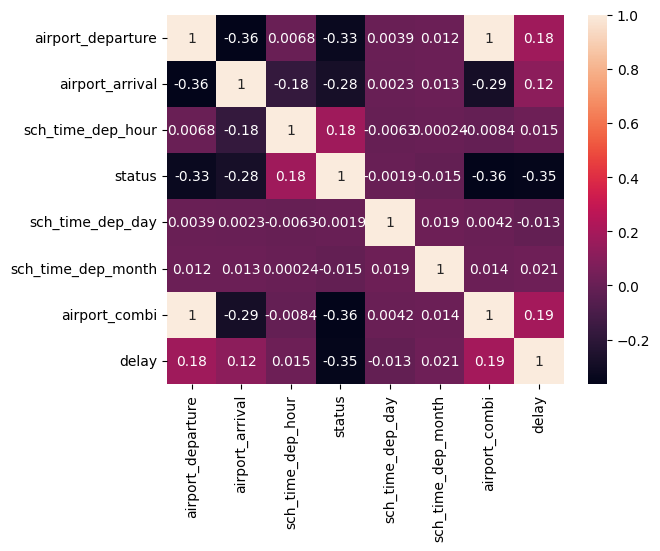

In [1100]:
sns.heatmap(data=df_train[["airport_departure", "airport_arrival", "sch_time_dep_hour", "status", "sch_time_dep_day", "sch_time_dep_month", "airport_combi","delay"]].corr(), annot=True)